In [2]:
# ============================================================
# BUSINESS VISUALIZATIONS
# Part 1
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ---------------------------------------------------
# Paths
# ---------------------------------------------------

DATA_FILE = "../data/processed/Combined_Data.xlsx"
OUTPUT = Path("../output/charts")

OUTPUT.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------
# Load Dataset
# ---------------------------------------------------

df = pd.read_excel(
    DATA_FILE,
    sheet_name="Support Tickets"
)

print(df.head())

# ---------------------------------------------------
# Convert Dates
# ---------------------------------------------------

df["Created Time (Ticket)"] = pd.to_datetime(
    df["Created Time (Ticket)"],
    dayfirst=True,
    errors="coerce"
)

# ---------------------------------------------------
# Company Colour Palette
# ---------------------------------------------------

PALETTE = {

    "primary":"#1f77b4",

    "secondary":"#ff7f0e",

    "success":"#2ca02c",

    "warning":"#d62728",

    "purple":"#9467bd"

}

print("Dataset Loaded Successfully")

   Ticket Id          Student or WP        Program Name Status (Ticket)  \
0       6403  Working Professionals   Fullstack Program          Closed   
1       6415  Working Professionals     Backend Program       Duplicate   
2       6420  Working Professionals   Fullstack Program          Closed   
3       6402                Student   Fullstack Program          Closed   
4       6423  Working Professionals  Fellowship Program          Closed   

  Created Time (Ticket) Ticket Closed Time First Response Time  \
0      14-05-2021 01:09   14-05-2021 19:04    14-05-2021 08:51   
1      14-05-2021 10:12   14-05-2021 11:23                 NaN   
2      14-05-2021 11:46   16-05-2021 00:09    14-05-2021 18:14   
3      14-05-2021 01:08   14-05-2021 19:04    14-05-2021 14:45   
4      14-05-2021 12:17   14-05-2021 20:39    14-05-2021 12:21   

       Project Phase  
0        trial phase  
1        trial phase  
2        trial phase  
3  fullstack-phase-1  
4        trial phase  
Dataset Loaded

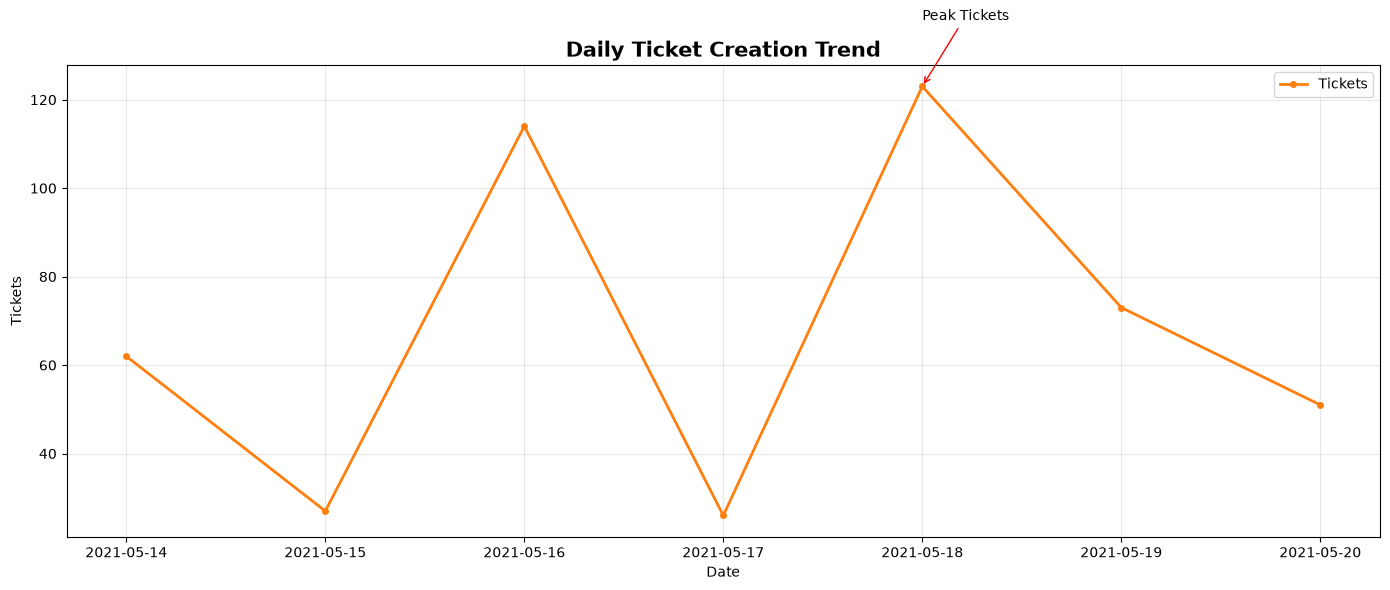

Chart 2 Saved


In [3]:
# ============================================================
# CHART 2
# Daily Ticket Trend
# ============================================================

daily = (

    df.groupby(

        df["Created Time (Ticket)"].dt.date

    )

    .size()

    .reset_index(name="Tickets")

)

fig, ax = plt.subplots(figsize=(14,6))

ax.plot(

    daily["Created Time (Ticket)"],

    daily["Tickets"],

    color=PALETTE["secondary"],

    linewidth=2,

    marker="o",

    markersize=4,

    label="Tickets"

)

ax.set_title(

    "Daily Ticket Creation Trend",

    fontsize=15,

    fontweight="bold"

)

ax.set_xlabel("Date")

ax.set_ylabel("Tickets")

ax.grid(alpha=.3)

ax.legend()

peak = daily["Tickets"].idxmax()

peak_date = daily.loc[peak,"Created Time (Ticket)"]

peak_value = daily.loc[peak,"Tickets"]

ax.annotate(

    "Peak Tickets",

    xy=(peak_date,peak_value),

    xytext=(peak_date,peak_value+15),

    arrowprops=dict(

        arrowstyle="->",

        color="red"

    ),

    fontsize=10

)

plt.tight_layout()

plt.savefig(

    OUTPUT/"chart2_daily_trend.png",

    dpi=300

)

plt.show()

print("Chart 2 Saved")

In [8]:
# ---------------------------------------------------
# Convert Date Columns
# ---------------------------------------------------

df["Created Time (Ticket)"] = pd.to_datetime(
    df["Created Time (Ticket)"],
    dayfirst=True,
    errors="coerce"
)

df["Ticket Closed Time"] = pd.to_datetime(
    df["Ticket Closed Time"],
    dayfirst=True,
    errors="coerce"
)

df["First Response Time"] = pd.to_datetime(
    df["First Response Time"],
    dayfirst=True,
    errors="coerce"
)

# ---------------------------------------------------
# Feature Engineering
# ---------------------------------------------------

# Resolution Time (Hours)

df["Resolution Hours"] = (
    df["Ticket Closed Time"] -
    df["Created Time (Ticket)"]
).dt.total_seconds() / 3600

# First Response Time (Hours)

df["First Response Hours"] = (
    df["First Response Time"] -
    df["Created Time (Ticket)"]
).dt.total_seconds() / 3600

# Ticket Creation Date

df["Date"] = df["Created Time (Ticket)"].dt.date

# Month

df["Month"] = df["Created Time (Ticket)"].dt.to_period("M").astype(str)

# Week

df["Week"] = df["Created Time (Ticket)"].dt.isocalendar().week

# Day Name

df["Day"] = df["Created Time (Ticket)"].dt.day_name()

print(df.head())

   Ticket Id          Student or WP        Program Name Status (Ticket)  \
0       6403  Working Professionals   Fullstack Program          Closed   
1       6415  Working Professionals     Backend Program       Duplicate   
2       6420  Working Professionals   Fullstack Program          Closed   
3       6402                Student   Fullstack Program          Closed   
4       6423  Working Professionals  Fellowship Program          Closed   

  Created Time (Ticket)  Ticket Closed Time First Response Time  \
0   2021-05-14 01:09:00 2021-05-14 19:04:00 2021-05-14 08:51:00   
1   2021-05-14 10:12:00 2021-05-14 11:23:00                 NaT   
2   2021-05-14 11:46:00 2021-05-16 00:09:00 2021-05-14 18:14:00   
3   2021-05-14 01:08:00 2021-05-14 19:04:00 2021-05-14 14:45:00   
4   2021-05-14 12:17:00 2021-05-14 20:39:00 2021-05-14 12:21:00   

       Project Phase  Resolution Hours  First Response Hours        Date  \
0        trial phase         17.916667              7.700000  2021-05-

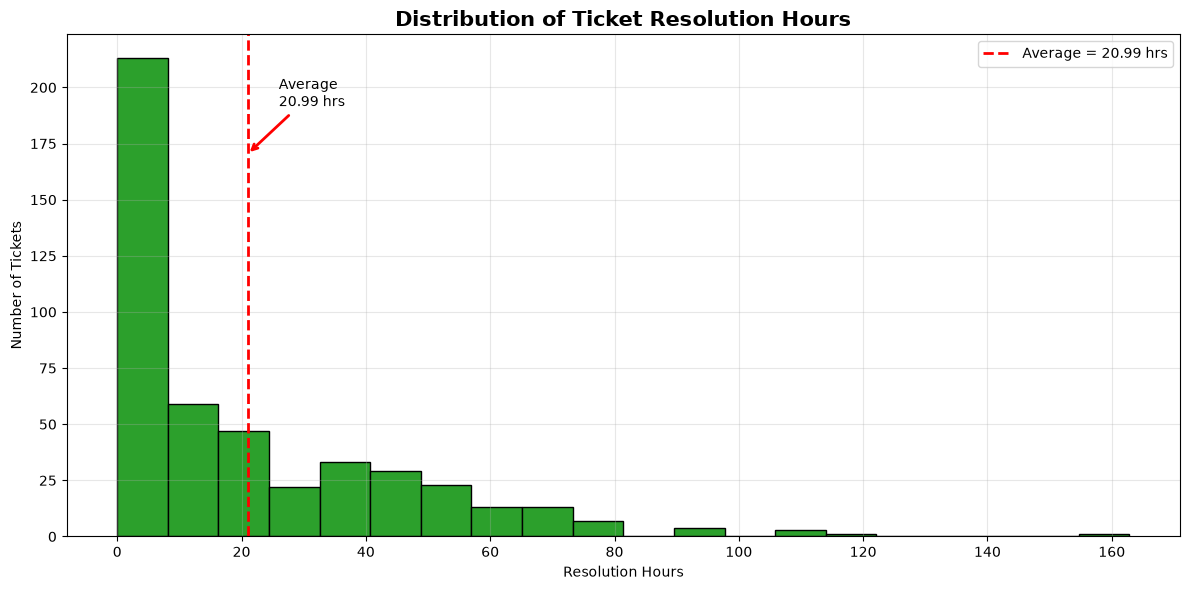

Chart 3 Saved


In [10]:
# ============================================================
# CHART 3
# Resolution Hours Distribution (Histogram)
# ============================================================

# Keep only valid resolution hours
resolution = df["Resolution Hours"]

resolution = resolution[
    resolution.notna() &
    (resolution >= 0)
]
fig, ax = plt.subplots(figsize=(12,6))

counts, bins, patches = ax.hist(
    resolution,
    bins=20,
    color=PALETTE["success"],
    edgecolor="black"
)

ax.set_title(
    "Distribution of Ticket Resolution Hours",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Resolution Hours")
ax.set_ylabel("Number of Tickets")

ax.grid(alpha=0.3)

# Mean annotation
mean_value = resolution.mean()

ax.axvline(
    mean_value,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Average = {mean_value:.2f} hrs"
)

ax.legend()

ymax = counts.max()

ax.annotate(
    f"Average\n{mean_value:.2f} hrs",
    xy=(mean_value, ymax*0.8),
    xytext=(mean_value+5, ymax*0.9),
    arrowprops=dict(
        arrowstyle="->",
        color="red",
        lw=2
    ),
    fontsize=10
)

plt.tight_layout()

plt.savefig(
    OUTPUT/"chart3_resolution_distribution.png",
    dpi=300
)

plt.show()

print("Chart 3 Saved")

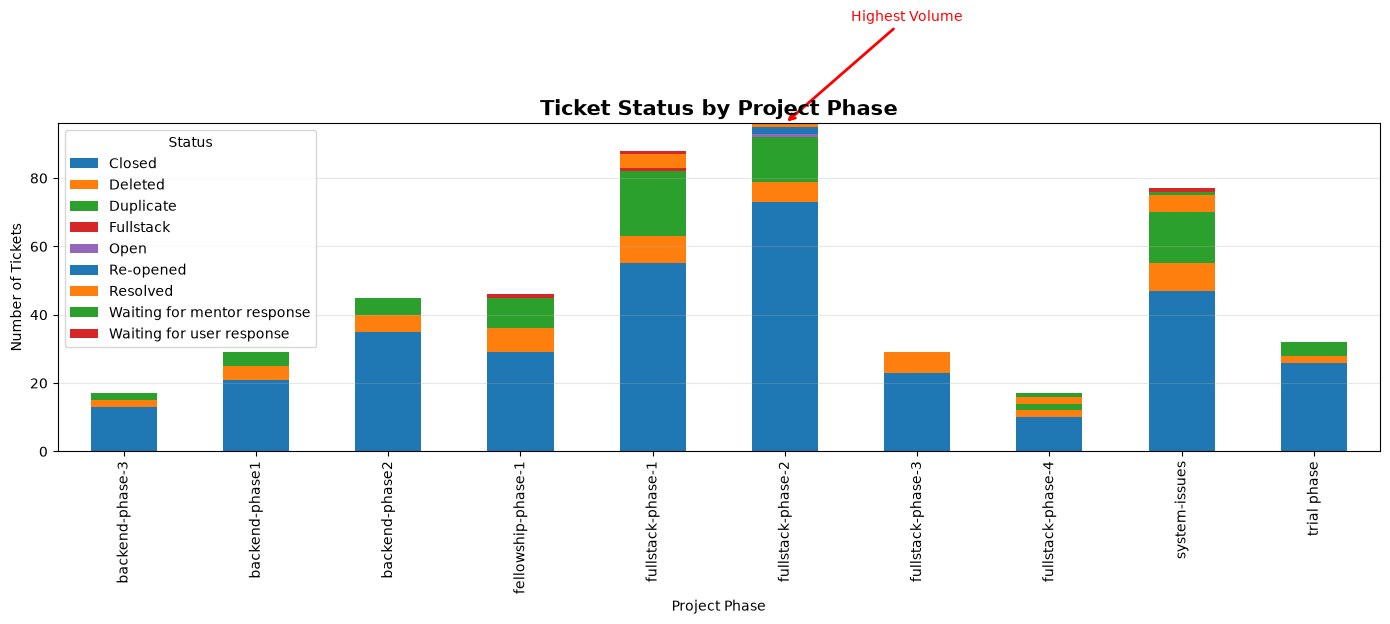

Chart 4 Saved


In [12]:
# ============================================================
# CHART 4
# Ticket Status by Project Phase
# ============================================================

status_phase = pd.crosstab(

    df["Project Phase"],

    df["Status (Ticket)"]

)

fig, ax = plt.subplots(figsize=(14,7))

status_phase.plot(

    kind="bar",

    stacked=True,

    ax=ax,

    color=[
        PALETTE["primary"],
        PALETTE["secondary"],
        PALETTE["success"],
        PALETTE["warning"],
        PALETTE["purple"]
    ]

)

ax.set_title(

    "Ticket Status by Project Phase",

    fontsize=15,

    fontweight="bold"

)

ax.set_xlabel("Project Phase")

ax.set_ylabel("Number of Tickets")

ax.legend(title="Status")

ax.grid(axis="y", alpha=.3)

# Annotate the tallest bar

totals = status_phase.sum(axis=1)

highest_phase = totals.idxmax()

highest_value = totals.max()

highest_index = list(status_phase.index).index(highest_phase)

ax.annotate(

    "Highest Volume",

    xy=(highest_index, highest_value),

    xytext=(highest_index+0.5, highest_value+30),

    arrowprops=dict(

        arrowstyle="->",

        color="red",

        lw=2

    ),

    fontsize=10,

    color="red"

)

plt.tight_layout()

plt.savefig(

    OUTPUT/"chart4_status_phase.png",

    dpi=300

)

plt.show()

print("Chart 4 Saved")